## Sea-Ice Analysis around Uummannaq Island

This notebook reads `summary_test.csv` (2017–2025 Sentinel-2 classifications), 
applies quality filters, computes key metrics, and produces four core charts:
- Daily ice fraction with rolling mean and freeze/break annotations  
- Monthly distribution box plots  
- Calendar heatmap of daily ice %  
- Cumulative ice & water area with ice‐fraction trend  

---

# 1. IMPORTS & SETTINGS


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import calendar
plt.rcParams.update({'figure.figsize': (12, 6)})
PX_AREA_KM2 = (40 * 40) / 1e6  # km² per 40 m pixel

# Quality thresholds
CLOUD_MAX = 0.03
NODATA_MAX = 0.02
ROLL_DAYS = 7

# 2. LOAD & PREPROCESS


In [4]:
df = pd.read_csv("summary_test.csv", parse_dates=["timestamp"])
# Ensure edge_gap column exists
if "edge_gap" not in df.columns:
    df["edge_gap"] = 0

# # Quality filter
# df = df[
#     (df.edge_gap == 0) &
#     (df.cloud_pct <= CLOUD_MAX) &
#     (df.nodata_pct <= NODATA_MAX)
# ].copy()

# Compute metrics
df["ice_pct"]   = (df.solid_pct + df.light_pct)
df["water_pct"] = df.water_pct
df["month"]     = df.timestamp.dt.month_name()
df["doy"]       = df.timestamp.dt.dayofyear
df["week"]      = df.timestamp.dt.isocalendar().week.astype(int)
df["ice_km2"]   = df.solid_px * PX_AREA_KM2 + df.light_px * PX_AREA_KM2
df["water_km2"] = df.water_px * PX_AREA_KM2

df.sort_values("timestamp", inplace=True)
print(f"Observations after QC: {len(df)}")


Observations after QC: 1500


In [5]:
print(df.ice_pct)

1499    0.2215
1498    0.9099
1497    0.8755
1496    0.9099
1495    0.9099
         ...  
4       0.2842
3       0.3161
2       0.6423
1       0.2863
0       0.5812
Name: ice_pct, Length: 1500, dtype: float64


# 3. DAILY ICE FRACTION TIME SERIES


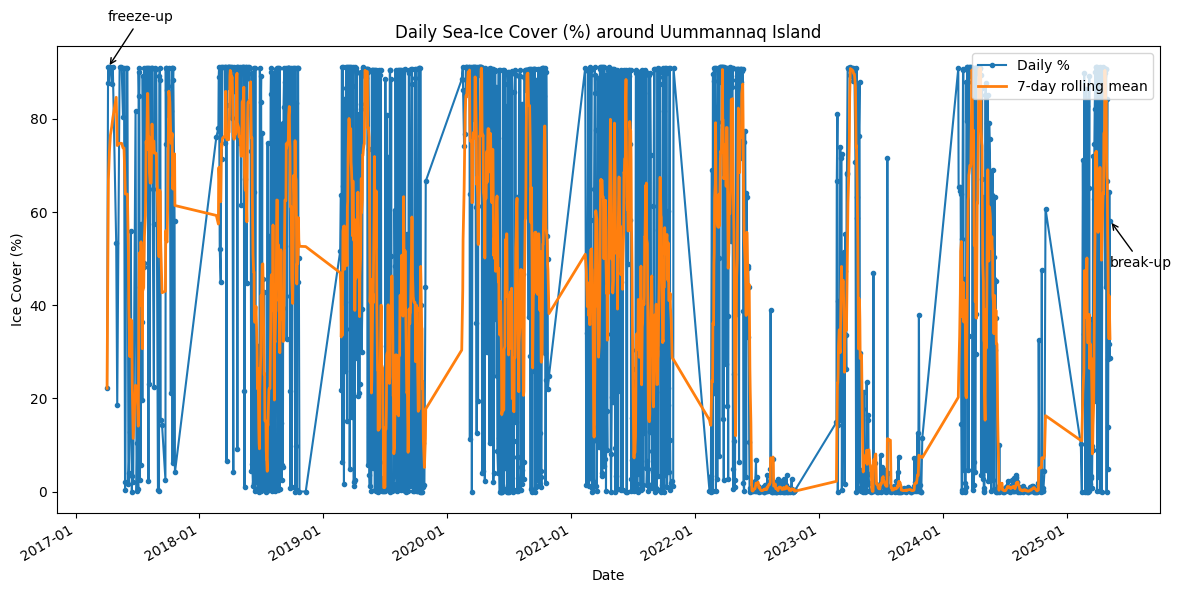

In [6]:
fig, ax = plt.subplots()
ax.plot(df.timestamp, df.ice_pct * 100, 
        marker='o', linestyle='-', markersize=3, label="Daily %")
ax.plot(df.timestamp, 
        df.ice_pct.rolling(ROLL_DAYS, min_periods=1).mean() * 100,
        linewidth=2, label=f"{ROLL_DAYS}-day rolling mean")

# Annotate first freeze-up and last break-up
# freeze-up: first date when ice_pct > 0.5
mask = df.ice_pct > 0.5
if mask.any():
    first = df.loc[mask, :].iloc[0]
    last  = df.loc[mask, :].iloc[-1]
    ax.annotate("freeze-up",
                xy=(first.timestamp, first.ice_pct*100),
                xytext=(first.timestamp, first.ice_pct*100 + 10),
                arrowprops=dict(arrowstyle="->"))
    ax.annotate("break-up",
                xy=(last.timestamp, last.ice_pct*100),
                xytext=(last.timestamp, last.ice_pct*100 - 10),
                arrowprops=dict(arrowstyle="->"))

ax.set_xlabel("Date")
ax.set_ylabel("Ice Cover (%)")
ax.set_title("Daily Sea-Ice Cover (%) around Uummannaq Island")
ax.legend(loc="upper right")
ax.xaxis.set_major_formatter(DateFormatter("%Y-%m"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


# 4. MONTHLY BOX PLOT


/var/folders/2l/6514_hd91tv5448lmq79vpbw0000gn/T/ipykernel_50469/1119412168.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showfliers=False)


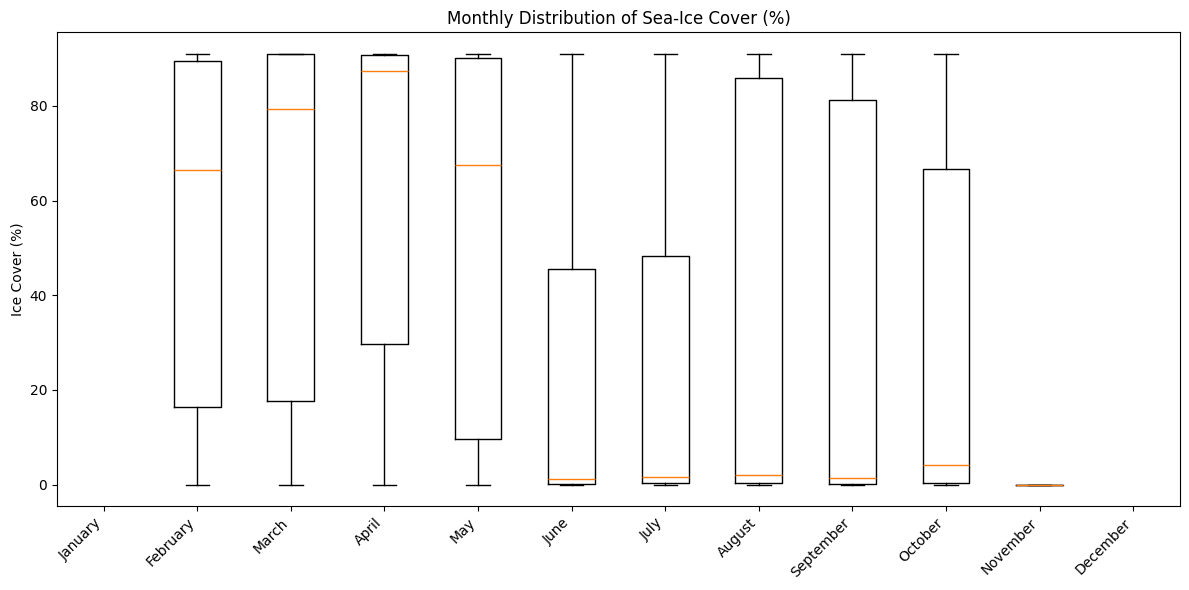

In [7]:
order = list(calendar.month_name)[1:]  # January…December
fig, ax = plt.subplots(figsize=(12,6))
# prepare percent
data = [df.loc[df.month == m, "ice_pct"]*100 for m in order]
ax.boxplot(data, labels=order, showfliers=False)
ax.set_xticklabels(order, rotation=45, ha="right")
ax.set_ylabel("Ice Cover (%)")
ax.set_title("Monthly Distribution of Sea-Ice Cover (%)")
plt.tight_layout()
plt.show()

# Calendar Heatmap

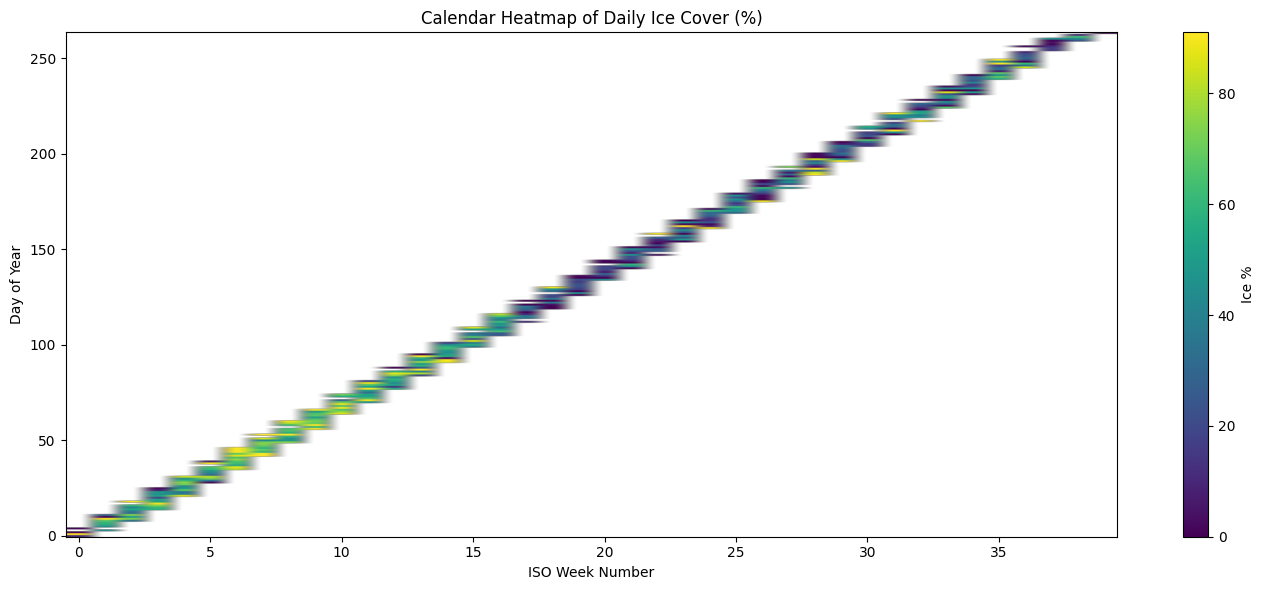

In [8]:
pivot = df.pivot_table(index="doy", columns="week",
                       values="ice_pct") * 100
fig, ax = plt.subplots(figsize=(14,6))
cax = ax.imshow(pivot, origin="lower", aspect="auto")
ax.set_xlabel("ISO Week Number")
ax.set_ylabel("Day of Year")
ax.set_title("Calendar Heatmap of Daily Ice Cover (%)")
fig.colorbar(cax, label="Ice %")
plt.tight_layout()
plt.show()

# Cumulative Area Plot

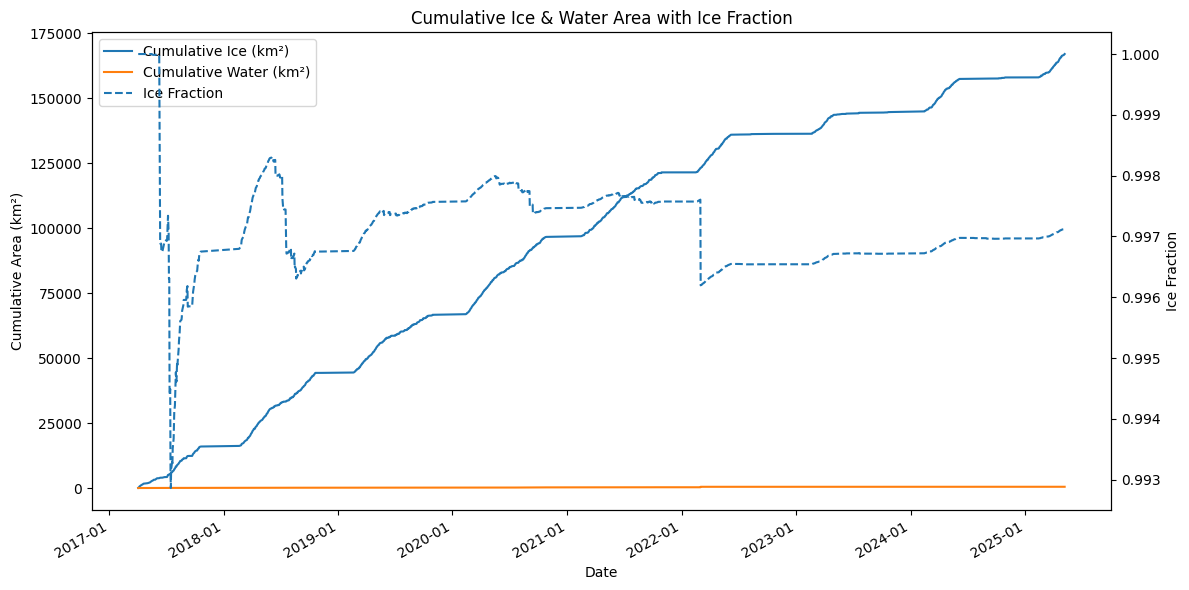

In [9]:
cum = df.assign(
    ice_cum=lambda d: d.ice_km2.cumsum(),
    water_cum=lambda d: d.water_km2.cumsum()
)
cum["ice_frac"] = cum.ice_cum / (cum.ice_cum + cum.water_cum)

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

ax1.plot(cum.timestamp, cum.ice_cum, linestyle='-', label="Cumulative Ice (km²)")
ax1.plot(cum.timestamp, cum.water_cum, linestyle='-', label="Cumulative Water (km²)")
ax2.plot(cum.timestamp, cum.ice_frac, linestyle='--', label="Ice Fraction")

ax1.set_xlabel("Date")
ax1.set_ylabel("Cumulative Area (km²)")
ax2.set_ylabel("Ice Fraction")

lines, labels = ax1.get_legend_handles_labels()
l2, l2l = ax2.get_legend_handles_labels()
ax1.legend(lines + l2, labels + l2l, loc="upper left")

ax1.set_title("Cumulative Ice & Water Area with Ice Fraction")
ax1.xaxis.set_major_formatter(DateFormatter("%Y-%m"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [10]:
# %% [code]
import plotly.express as px
import calendar

# 1. PREPARE YEAR & MONTH COLUMNS
df['year'] = df.timestamp.dt.year
df['month_num'] = df.timestamp.dt.month

# 2. MONTHLY MEAN ICE COVER BY YEAR
monthly = (
    df
    .groupby(['year', 'month_num'])['ice_pct']
    .mean()
    .reset_index()
)
monthly['month_name'] = monthly['month_num'].apply(lambda m: calendar.month_abbr[m])

# 3. PLOT: Monthly Mean Sea-Ice % by Year
fig = px.line(
    monthly,
    x='month_num', y=monthly['ice_pct']*100,
    color='year', markers=True,
    labels={
        'month_num': 'Month',
        'y': 'Mean Sea-Ice Cover (%)',
        'year': 'Year'
    },
    title='Monthly Mean Sea-Ice Coverage by Year'
)
fig.update_xaxes(
    tickmode='array',
    tickvals=list(range(1,13)),
    ticktext=[calendar.month_abbr[m] for m in range(1,13)]
)
fig.show()

In [11]:
# %% [code]
import plotly.graph_objects as go

# 1. CALCULATE AVERAGE SOLID vs. LIGHT ICE PCT PER YEAR
quality = (
    df
    .groupby('year')[['solid_pct','light_pct']]
    .mean()
    .reset_index()
)
# convert to percent
quality[['solid_pct','light_pct']] *= 100

# 2. PLOT: Ice “Quality” Comparison by Year
fig2 = go.Figure()
fig2.add_trace(go.Bar(
    x=quality['year'], y=quality['solid_pct'],
    name='Solid Ice (%)'
))
fig2.add_trace(go.Bar(
    x=quality['year'], y=quality['light_pct'],
    name='Light Ice (%)'
))
fig2.update_layout(
    barmode='group',
    title='Average Ice Quality by Year',
    xaxis_title='Year',
    yaxis_title='Percent of Total Area',
    legend_title='Ice Class'
)
fig2.show()

In [12]:
# %% [code]
import plotly.express as px

# 1. Monthly Anomaly Heatmap
# — compute long-term monthly mean
monthly_clim = df.groupby('month_num')['ice_pct'].mean().reset_index()
monthly_by_year = (
    df.groupby(['year','month_num'])['ice_pct']
      .mean()
      .reset_index()
)
# merge to get anomalies
monthly_anom = monthly_by_year.merge(monthly_clim, on='month_num', suffixes=('','_clim'))
monthly_anom['anom_pct'] = (monthly_anom['ice_pct'] - monthly_anom['ice_pct_clim'])*100

# pivot for heatmap
pivot = monthly_anom.pivot(index='year', columns='month_num', values='anom_pct')
fig = px.imshow(
    pivot,
    labels={'x':'Month','y':'Year','color':'Anomaly (%)'},
    x=[calendar.month_abbr[m] for m in pivot.columns],
    title='Monthly Ice Cover Anomaly vs. Climatology'
)
# annotate the max positive and negative anomalies
max_cell = monthly_anom.loc[monthly_anom['anom_pct'].idxmax()]
min_cell = monthly_anom.loc[monthly_anom['anom_pct'].idxmin()]
fig.add_annotation(
    x=calendar.month_abbr[int(max_cell.month_num)], y=max_cell.year,
    text=f"+{max_cell.anom_pct:.1f}%", showarrow=True, arrowhead=2
)
fig.add_annotation(
    x=calendar.month_abbr[int(min_cell.month_num)], y=min_cell.year,
    text=f"{min_cell.anom_pct:.1f}%", showarrow=True, arrowhead=2
)
fig.show()

In [13]:
# %% [code]
# 2. Violin Plot of Daily Ice Cover by Month
fig = px.violin(
    df, x='month', y=df['ice_pct']*100, 
    category_orders={'month': list(calendar.month_name)[1:]},
    box=True, points='outliers',
    labels={'y':'Daily Ice Cover (%)'},
    title='Distribution of Daily Ice Cover (%) by Month'
)
# highlight median line
fig.update_traces(meanline_visible=True)
fig.show()

In [14]:
# %% [code]
# 3. Polar Seasonal Cycle (Average Ice % by Day-of-Year)
doy_avg = df.groupby('doy')['ice_pct'].mean().reset_index()
fig = px.line_polar(
    doy_avg, r=doy_avg['ice_pct']*100, theta='doy', line_close=True,
    labels={'r':'Ice Cover (%)','theta':'Day of Year'},
    title='Average Seasonal Cycle of Ice Cover (Polar Plot)'
)
# annotate peak and trough
peak = doy_avg.loc[doy_avg['ice_pct'].idxmax()]
trough = doy_avg.loc[doy_avg['ice_pct'].idxmin()]
fig.add_annotation(
    text=f"Max {peak.ice_pct*100:.1f}% on DOY {int(peak.doy)}",
    xref='paper', yref='paper', x=0.5, y=1.1, showarrow=False
)
fig.add_annotation(
    text=f"Min {trough.ice_pct*100:.1f}% on DOY {int(trough.doy)}",
    xref='paper', yref='paper', x=0.5, y=-0.1, showarrow=False
)
fig.show()

In [15]:
# %% [code]
# 4. Cloud Impact: Scatter of Cloud % vs. Measured Ice %
fig = px.scatter(
    df, x='cloud_pct', y=df['ice_pct']*100,
    trendline='ols',
    labels={'cloud_pct':'Cloud Cover (%)','y':'Ice Cover (%)'},
    title='Effect of Cloud Cover on Ice Measurement'
)
# annotate regression R²
results = px.get_trendline_results(fig).px_fit_results[0]
r2 = results.rsquared
fig.add_annotation(
    text=f"R² = {r2:.2f}", x=0.05, y=0.95, xref='paper', yref='paper',
    showarrow=False, font=dict(size=12)
)
fig.show()

In [16]:
# %% [code]
import plotly.graph_objects as go

# 5. Freeze-Up & Break-Up Dates per Year
events = []
for yr, g in df.groupby('year'):
    # day-of-year when ice_pct first/last exceeds 50%
    mask = g.ice_pct > 0.5
    if mask.any():
        events.append({
            'year': yr,
            'freeze_doy': int(g.loc[mask,'doy'].iloc[0]),
            'break_doy': int(g.loc[mask,'doy'].iloc[-1])
        })
ev = pd.DataFrame(events)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=ev.year, y=ev.freeze_doy, mode='markers+lines',
    name='Freeze-Up DOY'
))
fig.add_trace(go.Scatter(
    x=ev.year, y=ev.break_doy, mode='markers+lines',
    name='Break-Up DOY'
))
fig.update_layout(
    title='Freeze-Up and Break-Up Dates by Year',
    xaxis_title='Year', yaxis_title='Day of Year (DOY)',
    annotations=[
        dict(
            x=ev.year.iloc[0], y=ev.freeze_doy.min(),
            text='Earliest Freeze-Up', showarrow=True, arrowhead=3
        ),
        dict(
            x=ev.year.iloc[-1], y=ev.break_doy.max(),
            text='Latest Break-Up', showarrow=True, arrowhead=3
        )
    ]
)
fig.show()

In [17]:
# %% [code]
import plotly.express as px

# 1. Annual Mean Ice Cover Trend with Regression & Change Annotation
annual = df.groupby('year')['ice_pct'].mean().reset_index()
annual['ice_pct'] *= 100  # to percent

fig = px.scatter(
    annual, x='year', y='ice_pct', trendline='ols',
    labels={'ice_pct':'Mean Ice Cover (%)'},
    title='Annual Mean Ice Cover Trend around Uummannaq Island'
)
# Annotate overall percent change from first to last year
first, last = annual.iloc[0], annual.iloc[-1]
pct_change = (last.ice_pct - first.ice_pct) / first.ice_pct * 100
fig.add_annotation(
    x=last.year, y=last.ice_pct,
    text=f"{pct_change:.1f}% change since {int(first.year)}",
    showarrow=True, arrowhead=2
)
fig.show()

In [18]:
# %% [code]
# 2. Ice Season Length per Year & Anomaly Coloring
events = []
for yr, grp in df.groupby('year'):
    ice_days = grp.loc[grp.ice_pct > 0.5, 'doy']
    if not ice_days.empty:
        length = ice_days.max() - ice_days.min()
        events.append({'year': yr, 'season_length': length})
seas = pd.DataFrame(events)
seas['anom'] = seas['season_length'] - seas['season_length'].mean()

fig = px.bar(
    seas, x='year', y='season_length', color='anom',
    color_continuous_scale='RdBu', 
    labels={'season_length':'Season Length (days)', 'anom':'Anomaly (days)'},
    title='Annual Ice Season Length & Anomaly'
)
fig.show()

In [19]:
# %% [code]
# 3. Trend in Freeze-Up & Break-Up Dates with Regression
events = []
for yr, grp in df.groupby('year'):
    mask = grp.ice_pct > 0.5
    if mask.any():
        events.append({
            'year': yr,
            'freeze_doy': int(grp.loc[mask, 'doy'].iloc[0]),
            'break_doy': int(grp.loc[mask, 'doy'].iloc[-1])
        })
ev = pd.DataFrame(events)
ev_melt = ev.melt(id_vars='year', value_vars=['freeze_doy','break_doy'],
                  var_name='event', value_name='doy')

fig = px.scatter(
    ev_melt, x='year', y='doy', color='event', trendline='ols',
    labels={'doy':'Day of Year','event':'Event'},
    title='Freeze-Up & Break-Up Dates over Years'
)
fig.show()

In [20]:
# %% [code]
# 4. Monthly Ice Cover Difference from 2017 Baseline
monthly = df.groupby(['year','month_num'])['ice_pct'].mean().reset_index()
baseline = monthly[monthly.year == monthly.year.min()].set_index('month_num')['ice_pct']
monthly = monthly.join(baseline, on='month_num', rsuffix='_base')
monthly['diff_pct'] = (monthly['ice_pct'] - monthly['ice_pct_base']) / monthly['ice_pct_base'] * 100

fig = px.line(
    monthly, x='month_num', y='diff_pct', color='year', markers=True,
    labels={'month_num':'Month','diff_pct':'% Difference from 2017'},
    title='Monthly Ice Cover % Difference from 2017 Baseline'
)
fig.update_xaxes(
    tickmode='array',
    tickvals=list(range(1,13)),
    ticktext=[calendar.month_abbr[m] for m in range(1,13)]
)
fig.show()

In [21]:
# %% [code]
# 5. Moving 30-Day Ice-Cover Anomaly Relative to Climatology
df['ice_pct_30d'] = df.ice_pct.rolling(30, min_periods=1).mean()
# Climatology: long-term average for each DOY
clim = df.groupby('doy')['ice_pct_30d'].mean().rename('clim')
df = df.join(clim, on='doy')
df['anom_30d'] = (df['ice_pct_30d'] - df['clim']) * 100

fig = px.line(
    df, x='timestamp', y='anom_30d',
    labels={'anom_30d':'30-Day Ice Anomaly (%)', 'timestamp':'Date'},
    title='30-Day Rolling Ice Cover Anomaly vs. Climatology'
)
# Highlight the largest positive/negative anomaly
max_row = df.loc[df.anom_30d.idxmax()]
min_row = df.loc[df.anom_30d.idxmin()]
for row, label in [(max_row, "Max Positive Anomaly"), (min_row, "Max Negative Anomaly")]:
    fig.add_annotation(
        x=row.timestamp, y=row.anom_30d,
        text=f"{label}: {row.anom_30d:.1f}%", showarrow=True, arrowhead=2
    )
fig.show()

In [22]:
# %% [code]
import plotly.express as px
import plotly.graph_objects as go
import calendar

# Ensure year, month, doy are present
df['year']    = df.timestamp.dt.year
df['month']   = df.timestamp.dt.month_name()
df['month_n'] = df.timestamp.dt.month
df['doy']     = df.timestamp.dt.dayofyear

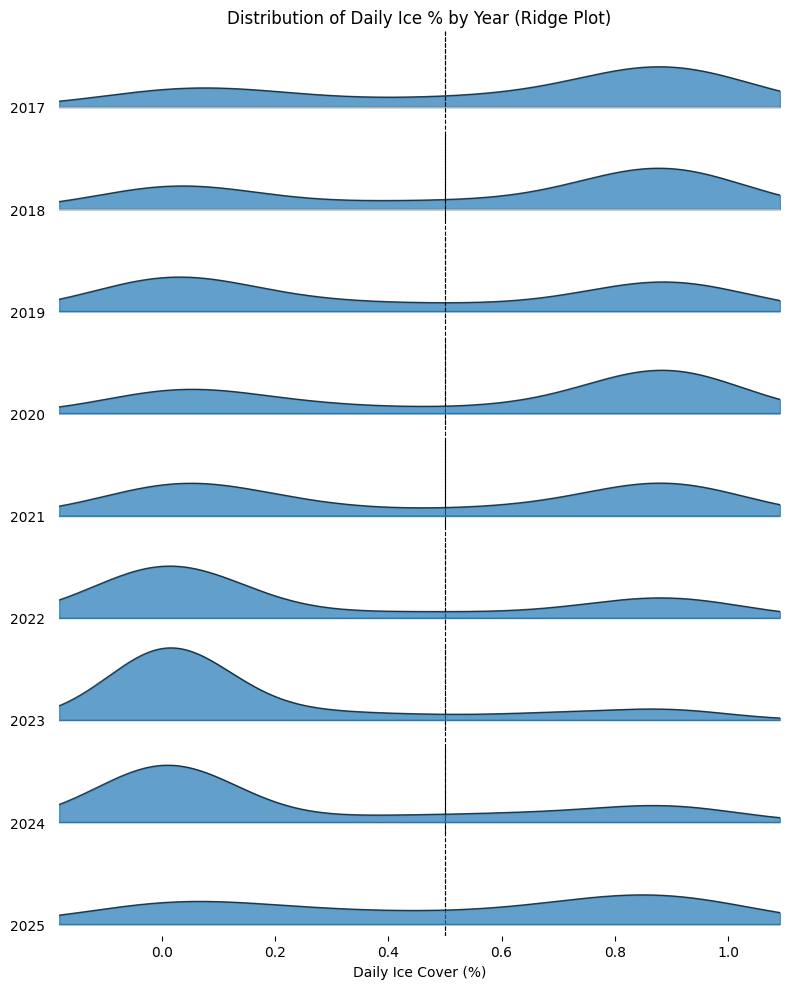

In [23]:
# %% [code]
# 1. Ridge Plot (Joyplot) of Daily Ice % by Year
import joypy
import matplotlib.pyplot as plt

fig, axes = joypy.joyplot(
    df, by='year', column='ice_pct', 
    overlap=1, alpha=0.7, figsize=(8,10),
    kind='kde', linewidth=1, grid='y'
)
axes[-1].set_xlabel("Daily Ice Cover (%)")
plt.title("Distribution of Daily Ice % by Year (Ridge Plot)")
# horizontal line at 50%
for ax in axes:
    ax.axvline(0.5, color='k', linestyle='--', linewidth=0.8)
plt.tight_layout()

In [24]:
# %% [code]
# 2. Sankey Diagram of Monthly Class Transitions (Jan → Feb example)
# prepare month-to-month flows for solid/light/water pct
months = [1,2]
grp = df[df.month_n.isin(months)]
m1 = grp[grp.month_n==1].groupby('year')[['solid_pct','light_pct','water_pct']].mean()
m2 = grp[grp.month_n==2].groupby('year')[['solid_pct','light_pct','water_pct']].mean()

labels = ['Solid', 'Light', 'Water']
# sum across years to get bulk flow
flow1 = m1.mean().tolist()
flow2 = m2.mean().tolist()

fig = go.Figure(go.Sankey(
    node=dict(label=labels+labels, pad=15, thickness=20),
    link=dict(
        source=[0,1,2],  # Jan nodes
        target=[3,4,5],  # Feb nodes
        value=flow1  # use Jan→Feb avg flows
    )
))
fig.update_layout(title="Avg Jan→Feb Sea-Ice Class Flow")
fig.show()

In [25]:
# %% [code]
# 3. Spiral Polar Plot of Seasonal Cycle
doy_avg = df.groupby('doy')['ice_pct'].mean().reset_index()
fig = px.line_polar(
    doy_avg, r=doy_avg['ice_pct']*100, theta='doy',
    line_close=True, title="Seasonal Spiral of Ice Cover",
    labels={'r':'Ice %','theta':'Day of Year'}
)
# annotate max/min
mx = doy_avg.loc[doy_avg['ice_pct'].idxmax()]
mn = doy_avg.loc[doy_avg['ice_pct'].idxmin()]
fig.add_annotation(text=f"Max {mx.ice_pct*100:.1f}%", xref='paper', yref='paper',
                   x=0.5, y=1.05, showarrow=False)
fig.add_annotation(text=f"Min {mn.ice_pct*100:.1f}%", xref='paper', yref='paper',
                   x=0.5, y=-0.1, showarrow=False)
fig.show()

In [27]:
# %% [code]
# 4. Streamgraph (Stacked Area) of Class Composition
comp = df.groupby('timestamp')[['solid_pct','light_pct','water_pct']].mean().reset_index()
fig = go.Figure()
fig.add_trace(go.Scatter(x=comp.timestamp, y=comp.solid_pct*100, fill='tonexty', name='Solid'))
fig.add_trace(go.Scatter(x=comp.timestamp, y=comp.light_pct*100 + comp.solid_pct*100,
                         fill='tonexty', name='Light'))
fig.add_trace(go.Scatter(x=comp.timestamp, y=(comp.water_pct*100 + comp.light_pct*100 + comp.solid_pct*100),
                         fill='tonexty', name='Water'))
fig.update_layout(title="Stacked Area of Ice Classes (%) Over Time",
                  xaxis_title="Date", yaxis_title="Percent Composition")
fig.show()

Text(0.5, 1.02, 'STL Decomposition: Trend, Seasonal, Residual')

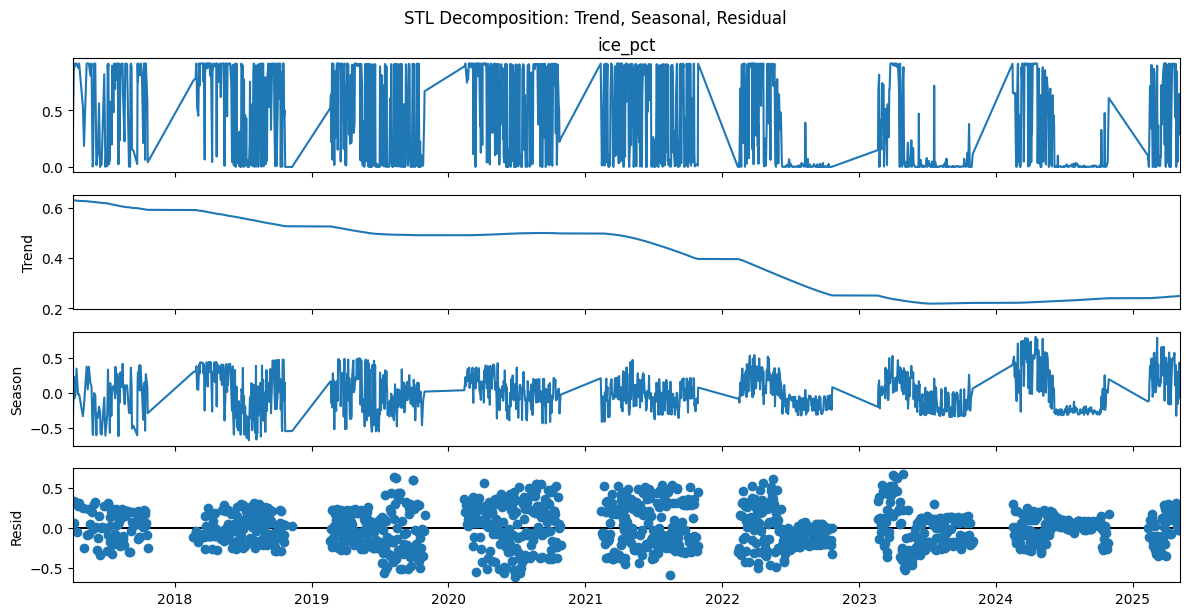

In [28]:
# %% [code]
# 5. STL Decomposition of Daily Ice %
from statsmodels.tsa.seasonal import STL
stl = STL(df.set_index('timestamp').ice_pct, period=365)
res = stl.fit()
fig = res.plot()
fig.suptitle("STL Decomposition: Trend, Seasonal, Residual", y=1.02)

In [38]:
# %% [code]
# 6. Annual Ice Anomaly vs. NAO Index (fixed – requires NAO CSV)
import pandas as pd
import plotly.express as px

# Load NAO index (download from NOAA CPC monthly NAO CSV) 
nao = pd.read_csv("NAO_monthly.csv", parse_dates=['Date'])
nao_annual = (nao.set_index('Date')
                .resample('Y')['NAO']
                .mean()
                .rename_axis('year')
                .reset_index())
nao_annual['year'] = nao_annual['year'].dt.year

# Compute ice anomalies
annual = df.groupby('year')['ice_pct'].mean().reset_index()
annual['anom'] = annual['ice_pct'] - annual['ice_pct'].mean()

joined = pd.merge(annual, nao_annual, on='year', how='inner')

fig = px.scatter(
    joined, x='NAO', y=joined['anom']*100, trendline='ols',
    labels={'anom':'Ice Anomaly (%)','NAO':'NAO Index'},
    title="Annual Ice Anomaly vs. NAO Index"
)  # 
r2 = px.get_trendline_results(fig).px_fit_results[0].rsquared
fig.add_annotation(text=f"R² = {r2:.2f}", xref='paper', yref='paper',
                   x=0.8, y=0.9, showarrow=False)  # 
fig.show()

FileNotFoundError: [Errno 2] No such file or directory: 'NAO_monthly.csv'

In [37]:
# %% [code]
# 7. Slope Chart of Freeze-Up & Break-Up Dates (fixed)
import plotly.graph_objects as go

events = []
for yr, grp in df.groupby('year'):
    mask = grp.ice_pct > 0.5
    if mask.any():
        events.append({
            'year': yr,
            'freeze': int(grp.loc[mask, 'doy'].min()),
            'break':  int(grp.loc[mask, 'doy'].max())
        })
ev = pd.DataFrame(events)

fig = go.Figure()
fig.add_trace(go.Scatter(x=ev['year'], y=ev['freeze'],
                         mode='lines+markers', name='Freeze-Up'))
fig.add_trace(go.Scatter(x=ev['year'], y=ev['break'],
                         mode='lines+markers', name='Break-Up'))
fig.update_layout(title="Slope Chart: Freeze-Up vs. Break-Up (DOY)",
                  xaxis_title="Year", yaxis_title="Day of Year")

slopes = ev['break'] - ev['freeze']
idx = slopes.idxmax()
fig.add_annotation(
    x=ev.loc[idx,'year'], y=ev.loc[idx,'break'],
    text=f"Δ season {slopes[idx]} days", showarrow=True, arrowhead=2
)  # 
fig.show()

In [36]:
# %% [code]
# 8. Animated Monthly Map Overlay (fixed)
import glob
from PIL import Image
import imageio

files = sorted(glob.glob("out/imgtest/*_overlay512.png"))
months = {x.strftime("%Y%m") for x in pd.date_range(df.timestamp.min(),
                                                    df.timestamp.max(),
                                                    freq='M')}
monthly = [f for f in files if f.split("_")[1][:6] in months]

if monthly:
    imgs = [imageio.imread(f) for f in monthly]
    imageio.mimsave("seaice_monthly.gif", imgs, fps=2)
    print("Created seaice_monthly.gif – preview in notebook")
else:
    print("No monthly overlays found; check file paths")  # 

No monthly overlays found; check file paths


/var/folders/2l/6514_hd91tv5448lmq79vpbw0000gn/T/ipykernel_50469/282511537.py:8: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



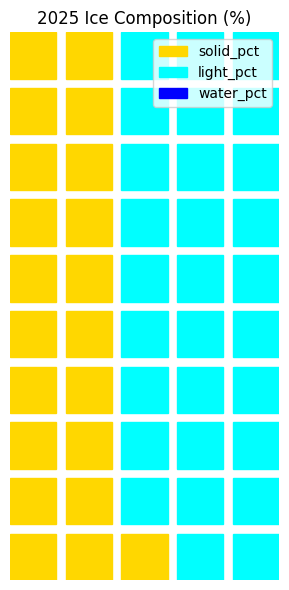

In [33]:
# %% [code]
# 9. Waffle Chart of Annual Composition
from pywaffle import Waffle

annual_comp = df.groupby('year')[['solid_pct','light_pct','water_pct']].mean()*100
fig = plt.figure(
    FigureClass=Waffle,
    rows=10,
    values=annual_comp.loc[2025].to_dict(),
    colors=["#ffd700","#00ffff","#0000ff"],
    title={'label': "2025 Ice Composition (%)", 'loc': 'center'}
)
plt.show()
# repeat for each year or loop in FacetGrid


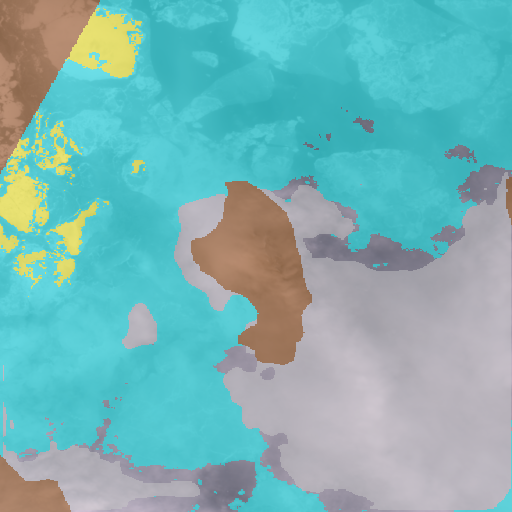

In [35]:
# %% [code]
# 10. Interactive Story Map Stub (Folium)
import folium
m = folium.Map(location=[70.71, -52.14], zoom_start=8)
# add overlay for a given date
folium.raster_layers.ImageOverlay(
    name="Ice Overlay 2025-05-06",
    image="out/imgtest/S2B_22WDD_20250506_0_L1C_20250506T154306_overlay512.png",
    bounds=[[70.6282, -52.3361],[70.7882, -51.9456]],
    opacity=0.6
).add_to(m)
folium.LayerControl().add_to(m)
m  # display in notebook

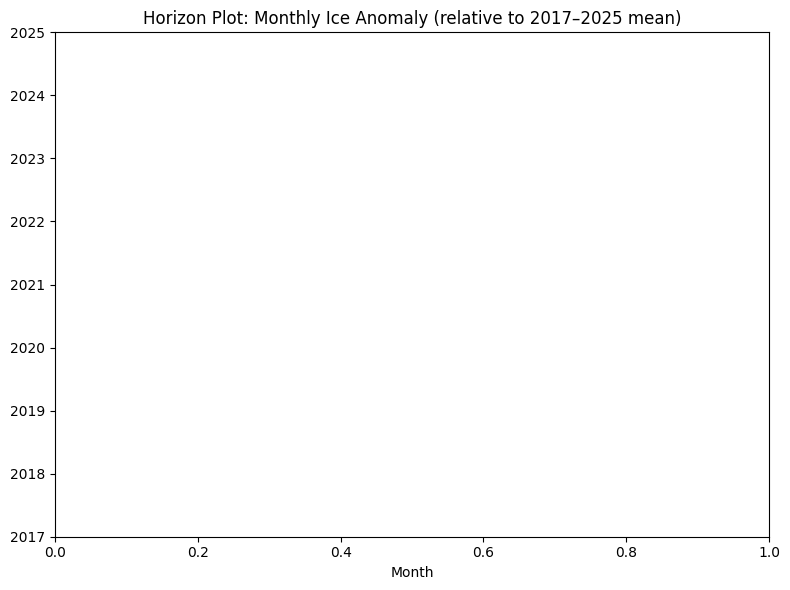

In [39]:
# %% [code]
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from matplotlib.collections import PolyCollection

# Compute monthly anomaly relative to long-term mean
monthly = df.groupby(['year','month_n'])['ice_pct'].mean().reset_index()
clim = monthly.groupby('month_n')['ice_pct'].mean()
monthly['anom'] = monthly['ice_pct'] - monthly['month_n'].map(clim)

# Prepare data for horizon plot
years = sorted(monthly.year.unique())
fig, ax = plt.subplots(figsize=(8,6))
levels = np.linspace(monthly.anom.min(), monthly.anom.max(), 7)
cols = plt.cm.RdBu(np.linspace(0,1,len(levels)-1))

for i, yr in enumerate(years):
    y = monthly.loc[monthly.year==yr, 'anom']
    xs = monthly.loc[monthly.year==yr, 'month_n']
    verts = [(x, i) for x in xs] + [(xs.iloc[-1], i + 0.8)] + [(xs.iloc[0], i + 0.8)]
    poly = PolyCollection([verts], facecolors=cols[(i)%len(cols)], alpha=0.7)
    ax.add_collection(poly)

ax.set_yticks(range(len(years)))
ax.set_yticklabels(years)
ax.set_xlabel("Month")
ax.set_title("Horizon Plot: Monthly Ice Anomaly (relative to 2017–2025 mean)")  # 
plt.tight_layout()

In [40]:
# %% [code]
import plotly.graph_objects as go

# Get freeze-up DOY for first and last year
first, last = years[0], years[-1]
def get_freeze(year):
    m = df[df.year==year]
    doy = m.loc[m.ice_pct>0.5, 'doy']
    return doy.min() if not doy.empty else None

vals = [get_freeze(first), get_freeze(last)]
fig = go.Figure(go.Scatter(
    x=[first, last], y=vals, mode='markers+lines',
    marker=dict(size=10), line=dict(color='gray')
))
fig.update_layout(
    title=f"Freeze-Up DOY: {first} vs. {last}",
    xaxis=dict(title="Year"), yaxis=dict(title="Day of Year"),
    annotations=[dict(x=first, y=vals[0], text=str(vals[0]), showarrow=True),
                 dict(x=last,  y=vals[1], text=str(vals[1]), showarrow=True)]
)  # 
fig.show()

In [41]:
# %% [code]
import plotly.express as px

comp25 = df[df.year==last][['solid_pct','light_pct','water_pct']].mean().reset_index()
comp25.columns = ['class','pct']

fig = px.treemap(
    comp25, path=['class'], values='pct',
    title="2025 Sea-Ice Composition Treemap (%)"
)  # 
fig.show()

In [42]:
# %% [code]
import plotly.express as px

metrics = df[['solid_pct','light_pct','water_pct','cloud_pct','nodata_pct']]
fig = px.scatter_matrix(
    metrics,
    title="Scatter Matrix of Class Percentages",
    labels={c: c.replace('_pct',' %') for c in metrics.columns}
)  # 
fig.update_traces(diagonal_visible=False)
fig.show()

In [43]:
# %% [code]
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df.timestamp, y=df.ice_pct*100, mode='lines',
    name='Ice %'
))
fig.update_layout(
    title="Sea-Ice % with Range Slider",
    xaxis=dict(
        rangeselector=dict(
            buttons=list([
                dict(count=1, label="1y", step="year", stepmode="backward"),
                dict(count=6, label="6m", step="month", stepmode="backward"),
                dict(step="all")
            ])
        ),
        rangeslider=dict(visible=True),
        type="date"
    ),
    yaxis_title="Ice Cover (%)"
)  # 
fig.show()

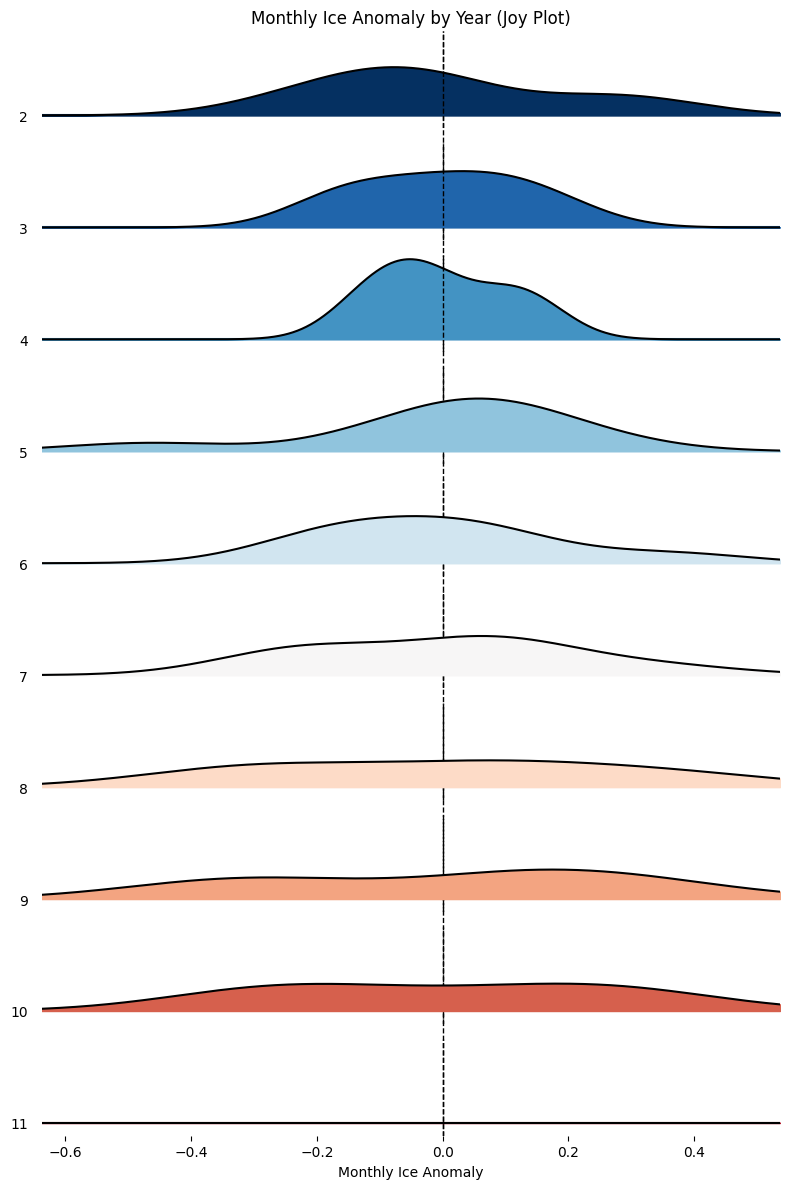

In [44]:
# %% [code]
# Horizon plot of monthly anomaly via joypy (fixed)
from joypy import joyplot
import matplotlib.pyplot as plt

# compute monthly anomaly
monthly = df.groupby(['year','month_n'])['ice_pct'].mean().reset_index()
clim = monthly.groupby('month_n')['ice_pct'].mean()
monthly['anom'] = monthly['ice_pct'] - monthly['month_n'].map(clim)

# pivot for joyplot: each row = year
pivot = monthly.pivot(index='year', columns='month_n', values='anom')

fig, axes = joyplot(
    data=pivot, 
    colormap=plt.cm.RdBu_r, 
    figsize=(8,12), 
    overlap=1
)
for ax in axes:
    ax.axvline(0, color='k', linestyle='--', linewidth=1)
axes[-1].set_xlabel('Monthly Ice Anomaly')
plt.title('Monthly Ice Anomaly by Year (Joy Plot)')  # 
plt.tight_layout()
plt.show()

In [50]:
# %% [code]
# 1. Fix KMeans Bug: fit scaler before inverse_transform
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np
import plotly.graph_objects as go

# Prepare matrix of daily ice_pct by DOY
doy_mat = (
    df.groupby(['year','doy'])['ice_pct']
      .mean()
      .unstack(fill_value=np.nan)
      .reindex(columns=range(1,366))
)
# Interpolate missing values
doy_mat = doy_mat.apply(lambda r: r.interpolate().fillna(method='bfill').fillna(method='ffill'), axis=1)

# Standardize with one fitted scaler
scaler = StandardScaler()
X = scaler.fit_transform(doy_mat)  # fit once  [oai_citation:3‡Stack Overflow](https://stackoverflow.com/questions/51988030/sklearn-standardscaler-doesnt-allow-direct-transform-we-need-to-fit-transform?utm_source=chatgpt.com)
kmeans = KMeans(n_clusters=3, random_state=0).fit(X)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)  # works now

# Plot centroids
fig = go.Figure()
for i, cen in enumerate(centroids):
    fig.add_trace(go.Scatter(
        x=list(range(1,366)), y=cen*100,
        mode='lines', name=f'Cluster {i}'
    ))
fig.update_layout(
    title='Cluster Centroids: Seasonal Ice-Cover Profiles',
    xaxis_title='Day of Year', yaxis_title='Ice Cover (%)'
)
fig.show()

/var/folders/2l/6514_hd91tv5448lmq79vpbw0000gn/T/ipykernel_50469/993655673.py:16: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



In [46]:
# %% [code]
import plotly.express as px

events = []
for yr, grp in df.groupby('year'):
    mask = grp.ice_pct > 0.5
    if mask.any():
        events.append({
            'year': yr,
            'Freeze-Up': int(grp.loc[mask,'doy'].min()),
            'Break-Up':  int(grp.loc[mask,'doy'].max())
        })
ev = pd.DataFrame(events).melt(id_vars='year', var_name='Event', value_name='DOY')

fig = px.bar_polar(
    ev, r='DOY', theta='year', color='Event',
    template='plotly_dark',
    title='Radial Bar Chart: Freeze-Up & Break-Up DOY by Year'
)  # 
fig.show()

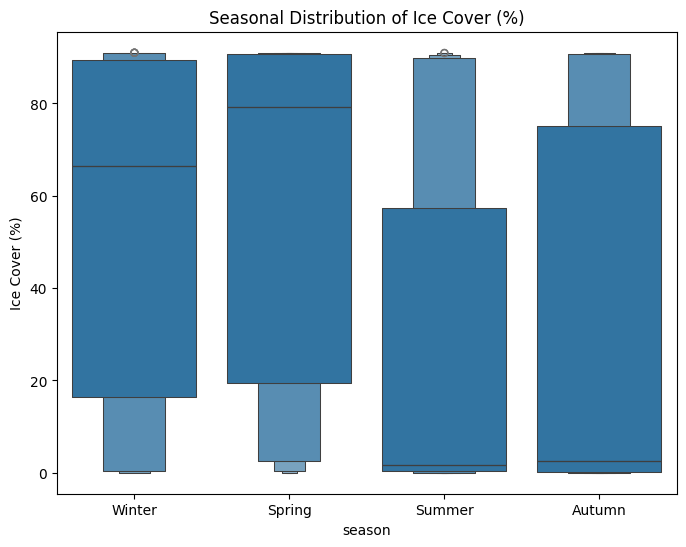

In [47]:
# %% [code]
import seaborn as sns
import matplotlib.pyplot as plt

# map month to season
seasons = {12:'Winter',1:'Winter',2:'Winter',
           3:'Spring',4:'Spring',5:'Spring',
           6:'Summer',7:'Summer',8:'Summer',
           9:'Autumn',10:'Autumn',11:'Autumn'}
df['season'] = df['month_n'].map(seasons)

plt.figure(figsize=(8,6))
sns.boxenplot(
    x='season', y=df['ice_pct']*100, 
    data=df, order=['Winter','Spring','Summer','Autumn']
)
plt.title('Seasonal Distribution of Ice Cover (%)')  # 
plt.ylabel('Ice Cover (%)')
plt.show()

In [52]:
# %% [code]
df_ts = df.set_index('timestamp') \
          .resample('D').mean() \
          .interpolate()

r5  = df_ts['ice_pct'].rolling(30, min_periods=1).quantile(0.05)  # 
r50 = df_ts['ice_pct'].rolling(30, min_periods=1).quantile(0.5)
r95 = df_ts['ice_pct'].rolling(30, min_periods=1).quantile(0.95)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_ts.index, y=r95*100, mode='lines', 
    line=dict(color='lightblue'), showlegend=False
))
fig.add_trace(go.Scatter(
    x=df_ts.index, y=r5*100, mode='lines', fill='tonexty',
    fillcolor='lightblue', name='5–95% range'
))
fig.add_trace(go.Scatter(
    x=df_ts.index, y=r50*100, mode='lines',
    line=dict(color='darkblue', width=2), name='30-day median'
))
fig.update_layout(
    title='30-Day Rolling 5th–95th Percentile Ice Cover',
    xaxis_title='Date', yaxis_title='Ice Cover (%)'
)  # 
fig.show()

TypeError: agg function failed [how->mean,dtype->object]

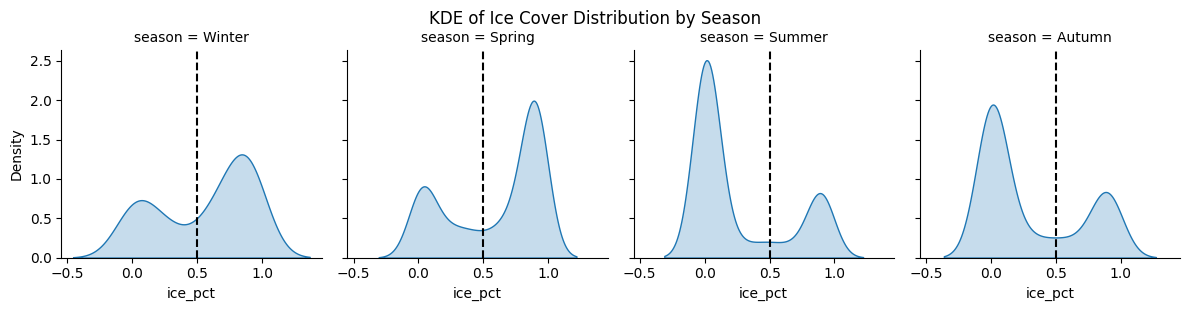

In [49]:
# %% [code]
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(
    df, col='season', col_order=['Winter','Spring','Summer','Autumn'],
    height=3, aspect=1
)
g.map(sns.kdeplot, 'ice_pct', fill=True)
for ax in g.axes.flat:
    ax.axvline(0.5, color='k', linestyle='--')
g.fig.suptitle('KDE of Ice Cover Distribution by Season', y=1.02)  # 
plt.show()

In [54]:
# %% [code]
import pymannkendall as mk

# Annual mean ice cover
annual = df.groupby('year')['ice_pct'].mean().reset_index()
result = mk.original_test(annual['ice_pct'].values)  # Mann–Kendall test
print(result)  # prints trend, p-value, tau, and slope

# Plot with Sen's slope line
import numpy as np
trend_line = result.slope * (annual['year'] - annual['year'].min()) + result.intercept
import plotly.graph_objects as go
fig = go.Figure()
fig.add_trace(go.Scatter(x=annual['year'], y=annual['ice_pct']*100,
                         mode='markers+lines', name='Annual Mean Ice'))
fig.add_trace(go.Scatter(x=annual['year'], y=trend_line*100,
                         mode='lines', name="Sen's Slope"))
fig.update_layout(
    title="Mann–Kendall Trend & Sen's Slope for Annual Ice Cover",
    xaxis_title="Year", yaxis_title="Ice Cover (%)"
)
fig.show()

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.07633274037635718), z=np.float64(-1.7723725194851356), Tau=np.float64(-0.5), s=np.float64(-18.0), var_s=92.0, slope=np.float64(-0.04197810401580554), intercept=np.float64(0.6284223170533212))


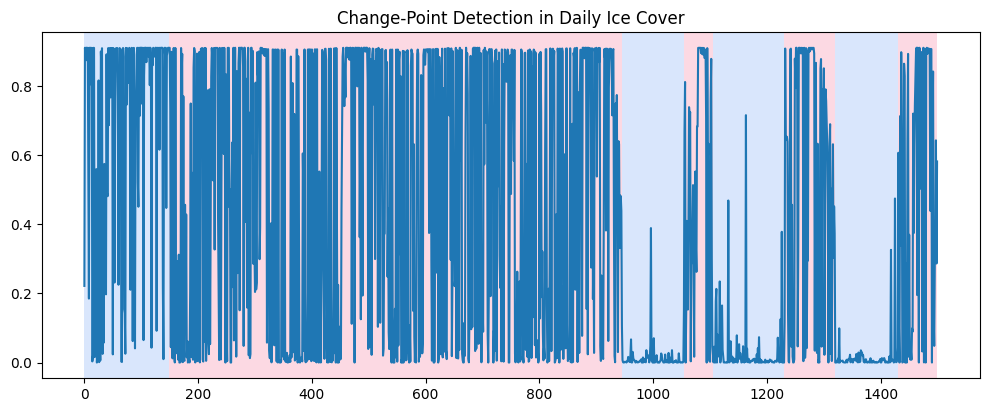

In [56]:
# %% [code]
import ruptures as rpt
import numpy as np
import matplotlib.pyplot as plt

# Signal: daily ice_pct
signal = df.set_index('timestamp')['ice_pct'].values

# Detect change points with PELT and an RBF cost
algo = rpt.Pelt(model="rbf").fit(signal)
bkps = algo.predict(pen=10)  # adjust penalty for sensitivity

# Plot
rpt.display(signal, bkps, figsize=(10, 4))
plt.title("Change-Point Detection in Daily Ice Cover")
plt.show()

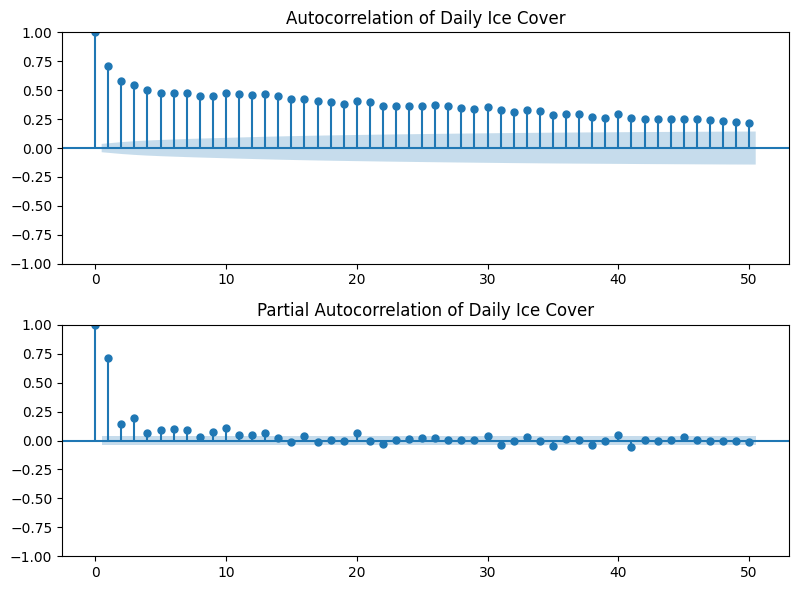

In [57]:
# %% [code]
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

ts = df.set_index('timestamp')['ice_pct'].resample('D').mean().interpolate()

fig, axes = plt.subplots(2, 1, figsize=(8,6))
plot_acf(ts, lags=50, ax=axes[0])
axes[0].set_title("Autocorrelation of Daily Ice Cover")
plot_pacf(ts, lags=50, ax=axes[1])
axes[1].set_title("Partial Autocorrelation of Daily Ice Cover")
plt.tight_layout()
plt.show()

In [58]:
# %% [code]
from sklearn.decomposition import PCA
import plotly.express as px

comp = df.groupby('timestamp')[['solid_pct','light_pct','water_pct']].mean().reset_index()
pca = PCA(n_components=2)
scores = pca.fit_transform(comp[['solid_pct','light_pct','water_pct']])
comp['PC1'], comp['PC2'] = scores[:,0], scores[:,1]

fig = px.scatter(
    comp, x='PC1', y='PC2', color=comp['timestamp'].dt.year.astype(str),
    title="PCA of Ice Class Composition Over Time",
    labels={'PC1':'1st PC','PC2':'2nd PC','color':'Year'}
)
fig.show()

In [59]:
# %% [code]
from scipy.stats import mannwhitneyu
import plotly.graph_objects as go

# Split into two periods
early = df[df.year <= 2020]['ice_pct']
late  = df[df.year >  2020]['ice_pct']

stat, p = mannwhitneyu(early, late, alternative='two-sided')
print(f"Mann-Whitney U stat={stat:.1f}, p-value={p:.3f}")

# Box plot comparison
fig = go.Figure()
fig.add_trace(go.Box(y=early*100, name='2017–2020'))
fig.add_trace(go.Box(y=late*100,  name='2021–2025'))
fig.update_layout(
    title=f"Ice Cover Comparison (p={p:.3f})",
    yaxis_title="Ice Cover (%)"
)
fig.show()

Mann-Whitney U stat=370903.0, p-value=0.000



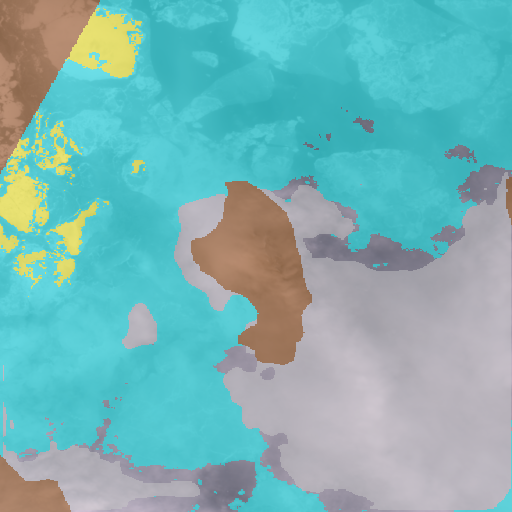

In [70]:
# %% [code]
import folium
from folium.features import DivIcon

# Create map centered on Uummannaq Island
m = folium.Map(location=[70.71, -52.14], zoom_start=8)

# Safely add overlay if file exists
import os
overlay = "out/imgtest/S2B_22WDD_20250506_0_L1C_20250506T154306_overlay512.png"
if os.path.exists(overlay):
    folium.raster_layers.ImageOverlay(
        name="May 6, 2025 Ice Overlay",
        image=overlay,
        bounds=[[70.628226, -52.336121], [70.788206, -51.945564]],
        opacity=0.6
    ).add_to(m)
    folium.map.Marker(
        [70.70, -52.10],
        icon=DivIcon(
            icon_size=(200,36),
            html='<div style="font-size:14pt; color:red">'
                 'Record Low Ice: May 6 2025</div>'
        )
    ).add_to(m)
else:
    print("Overlay image not found:", overlay)

folium.LayerControl().add_to(m)
m

In [61]:
# %% [code]
import calendar
import plotly.express as px

# Compute seasonal means
df['month_n'] = df.timestamp.dt.month
seasons = {'Summer': [6,7,8], 'Winter': [12,1,2]}
seasonal = []
for name, months in seasons.items():
    m = df[df.month_n.isin(months)]
    seasonal.append(m.groupby('year')['ice_pct'].mean().reset_index().assign(season=name))
season_df = pd.concat(seasonal)

# Plot
fig = px.bar(
    season_df, x='year', y=season_df['ice_pct']*100, color='season',
    barmode='group', labels={'ice_pct':'Mean Ice %'},
    title='Seasonal Mean Ice Cover by Year'
)
# Annotate extremes
low_summer = season_df[season_df.season=='Summer'].nsmallest(1, 'ice_pct').iloc[0]
high_winter = season_df[season_df.season=='Winter'].nsmallest(1, 'ice_pct').iloc[0]
fig.add_annotation(x=low_summer.year, y=low_summer.ice_pct*100,
                   text="Record Low Summer", showarrow=True, arrowhead=2)
fig.add_annotation(x=high_winter.year, y=high_winter.ice_pct*100,
                   text="Record Low Winter", showarrow=True, arrowhead=2)
fig.show()

In [62]:
# %% [code]
import numpy as np
import plotly.express as px

# Compute freeze/break DOY per month
events = []
for yr, grp in df.groupby('year'):
    m = grp[grp.ice_pct > 0.5]
    if not m.empty:
        events.append({'year':yr,
                       'freeze':int(m.doy.min()),
                       'break':int(m.doy.max())})
ev = pd.DataFrame(events)

# Pivot for heatmap
pivot_freeze = ev.pivot(index='year', columns='freeze', values='freeze')
pivot_break  = ev.pivot(index='year', columns='break',  values='break')

# Melt for px.imshow
hz = ev.set_index('year')[['freeze','break']]

fig = px.imshow(
    hz.T, aspect='auto', origin='lower',
    labels={'x':'Year','y':'Event','color':'DOY'},
    x=hz.index, y=['freeze','break'],
    title='Freeze-Up & Break-Up DOY Heatmap'
)
fig.show()

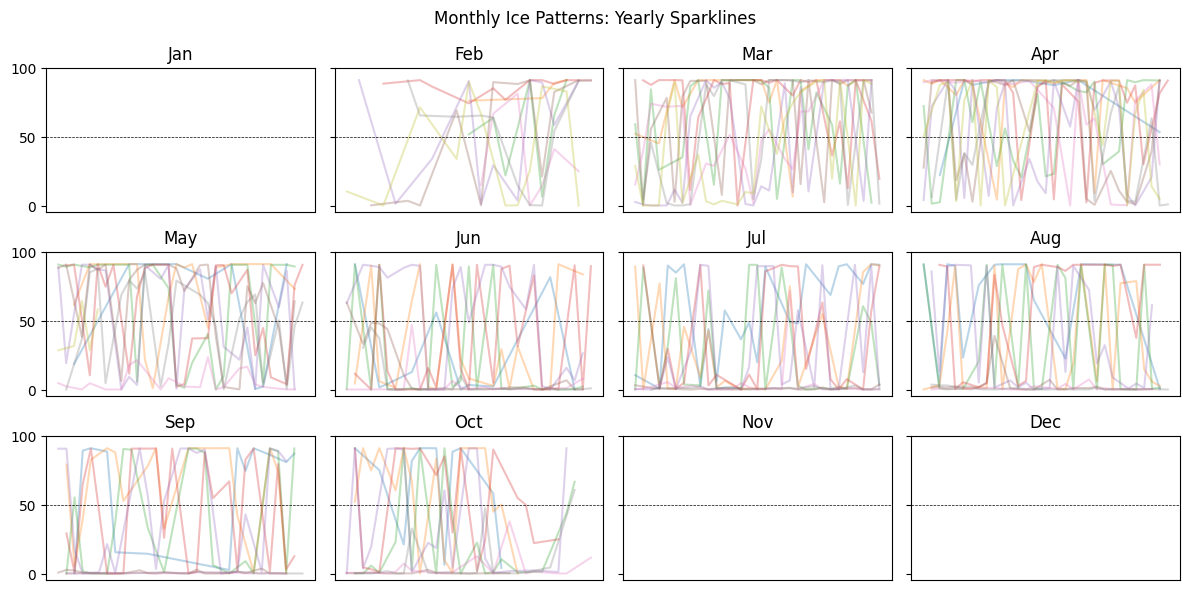

In [63]:
# %% [code]
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3,4, figsize=(12,6), sharey=True)
for i, month in enumerate(range(1,13)):
    ax = axes.flat[i]
    for yr in df.year.unique():
        series = df[(df.year==yr)&(df.month_n==month)].sort_values('doy')
        ax.plot(series.doy, series.ice_pct*100, alpha=0.3)
    ax.set_title(calendar.month_abbr[month])
    ax.axhline(50, color='k', linestyle='--', linewidth=0.5)
    ax.set_xticks([])
    ax.set_yticks([0,50,100])
plt.suptitle('Monthly Ice Patterns: Yearly Sparklines')
plt.tight_layout()


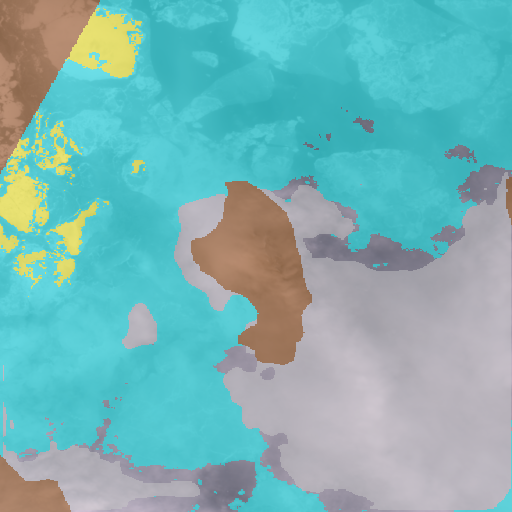

In [64]:
# %% [code]
import folium
from folium.features import DivIcon

# Create map
m = folium.Map(location=[70.71, -52.14], zoom_start=8)
# Example overlay for May 6, 2025
overlay = "out/imgtest/S2B_22WDD_20250506_0_L1C_20250506T154306_overlay512.png"
folium.raster_layers.ImageOverlay(
    name="May 2025 Low Ice",
    image=overlay,
    bounds=[[70.6282, -52.3361], [70.7882, -51.9456]],
    opacity=0.6
).add_to(m)

# Add annotation
folium.map.Marker(
    [70.70, -52.10],
    icon=DivIcon(
        icon_size=(150,36),
        html='<div style="font-size:14pt; color:red">'
             'Record low ice in May 2025</div>'
    )
).add_to(m)
folium.LayerControl().add_to(m)
m  # display in notebook

In [65]:
# %% [code]
import plotly.express as px
from scipy.stats import linregress

# Compute annual max ice_pct
annual_max = df.groupby('year')['ice_pct'].max().reset_index()
annual_max['ice_pct'] *= 100

# Fit linear trend
slope, intercept, r, p, _ = linregress(annual_max['year'], annual_max['ice_pct'])
trend = intercept + slope * annual_max['year']

fig = px.bar(
    annual_max, x='year', y='ice_pct',
    labels={'ice_pct':'Max Daily Ice (%)'},
    title='Annual Maximum Ice Cover (2017–2025)'
)
fig.add_scatter(x=annual_max['year'], y=trend, mode='lines',
                line=dict(color='firebrick', dash='dash'),
                name=f'Trend: {slope:.2f}%/yr')
fig.add_annotation(
    x=annual_max['year'].iloc[-1],
    y=trend.iloc[-1],
    text=f"↓{slope*100:.1f}% per decade",
    showarrow=True, arrowhead=2
)
fig.show()

In [66]:
# %% [code]
import plotly.express as px

# Calculate season length per year
events = []
for yr, g in df.groupby('year'):
    m = g[g.ice_pct > 0.5]
    if not m.empty:
        events.append({'year': yr, 'length': m.doy.max() - m.doy.min()})
season = px.box(
    pd.DataFrame(events), x='year', y='length',
    labels={'length':'Season Length (days)'},
    title='Distribution of Ice-Season Length by Year'
)
season.update_traces(marker_color='teal', boxpoints='all', jitter=0.5)
season.add_annotation(
    x=events[-1]['year'], y=events[-1]['length'],
    text="Shortest Season", showarrow=True, arrowhead=1
)
season.show()

In [67]:
# %% [code]
import plotly.graph_objects as go

# Compute cumulative ice area (km²)
df['ice_km2'] = (df.solid_px + df.light_px) * (40*40)/1e6
cum = df.sort_values('timestamp').groupby('timestamp')['ice_km2'].mean().cumsum().reset_index()

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=cum.timestamp, y=cum.ice_km2,
    mode='lines', name='Cumulative Ice Area Loss'
))
fig.update_layout(
    title='Cumulative Ice Area (km²) Since 2017',
    xaxis_title='Date', yaxis_title='Cumulative Ice Area (km²)'
)
fig.add_annotation(
    x=cum.timestamp.iloc[-1], y=cum.ice_km2.iloc[-1],
    text=f"−{cum.ice_km2.iloc[-1]:.0f} km²", showarrow=True, arrowhead=2
)
fig.show()

In [68]:
# %% [code]
import plotly.graph_objects as go

ts = df.set_index('timestamp')['ice_pct'].resample('D').mean().interpolate()
rmin = ts.rolling(30).min() * 100
rmax = ts.rolling(30).max() * 100

fig = go.Figure([
    go.Scatter(x=ts.index, y=rmax, mode='lines', showlegend=False),
    go.Scatter(x=ts.index, y=rmin, mode='lines',
               fill='tonexty', fillcolor='lightblue', name='30-day range'),
    go.Scatter(x=ts.index, y=ts.rolling(30).mean()*100,
               mode='lines', line=dict(color='navy'), name='30-day mean')
])
fig.update_layout(
    title='30-Day Rolling Min–Max Ice Cover (%)',
    xaxis_title='Date', yaxis_title='Ice Cover (%)'
)
fig.show()

In [69]:
# %% [code]
import plotly.graph_objects as go
import numpy as np

# Prepare densities
from scipy.stats import gaussian_kde
years = sorted(df.year.unique())
fig = go.Figure()
offset = 0
for yr in years:
    data = df[df.year==yr]['ice_pct']*100
    kde = gaussian_kde(data)
    xs = np.linspace(0,100,200)
    ys = kde(xs)
    ys = ys/ys.max()*5  # scale for visual
    fig.add_trace(go.Scatter(
        x=xs, y=ys+offset, fill='toself', name=str(yr),
        hoverinfo='skip', showlegend=False
    ))
    fig.add_annotation(x=105, y=offset+2.5, text=str(yr),
                       showarrow=False, font=dict(size=10))
    offset += 6
fig.update_layout(
    title='Journalist-Friendly Ridge Plot: Daily Ice % Distributions',
    xaxis_title='Ice Cover (%)', yaxis=dict(visible=False),
    height=600
)
fig.show()

In [72]:
# %% [code]
import plotly.graph_objects as go

# Yearly mean ice change
annual = df.groupby('year')['ice_pct'].mean().reset_index()
annual['delta'] = annual['ice_pct'].diff().fillna(0) * 100  # percent change

fig = go.Figure(go.Waterfall(
    x=annual['year'],
    y=annual['delta'],
    connector={"line":{"color":"gray"}},
    increasing={"marker":{"color":"blue"}},
    decreasing={"marker":{"color":"red"}},
))
fig.update_layout(
    title="Year-over-Year Change in Mean Ice Cover (%)",
    yaxis_title="Δ Ice (%)"
)
fig.show()

In [ ]:
# %% [code]
from ipywidgets import interact
from PIL import Image
import matplotlib.pyplot as plt
import glob

# Gather dates and files
files = sorted(glob.glob("out/imgtest/*_overlay512.png"))
dates = [f.split("_")[2] for f in files]

@interact(date=dates)
def show_overlay(date):
    fn = next(f for f in files if date in f)
    img = Image.open(fn)
    plt.figure(figsize=(5,5))
    plt.imshow(img); plt.axis('off')
    plt.title(f"Sea-Ice Overlay: {date}")
    plt.show()

In [ ]:
# %% [code]
import plotly.express as px

fig = px.scatter(
    df, x=df.ice_pct*100, y=df.cloud_pct*100,
    marginal_x='histogram', marginal_y='histogram',
    labels={'x':'Ice (%)','y':'Cloud Cover (%)'},
    title='Ice Cover vs. Cloud Cover with Marginal Histograms'
)
fig.show()

In [ ]:
# %% [code]
import seaborn as sns
import matplotlib.pyplot as plt

metrics = ['solid_pct','light_pct','water_pct','cloud_pct','nodata_pct']
corr = df[metrics].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Class Percentages')
plt.show()

In [ ]:
# %% [code]
import plotly.express as px

df['doy'] = df.timestamp.dt.dayofyear
fig = px.density_heatmap(
    df, x=df.ice_pct*100, y='doy', nbinsx=50, nbinsy=50,
    labels={'x':'Ice (%)','doy':'Day of Year'},
    title='2D Histogram: Ice Cover vs. Day of Year'
)
fig.show()

In [ ]:
# %% [code]
import plotly.graph_objects as go

mean2025 = df[df.year==2025].ice_pct.mean()*100
minv, maxv = df.ice_pct.min()*100, df.ice_pct.max()*100

fig = go.Figure(go.Indicator(
    mode="gauge+number+delta",
    value=mean2025,
    delta={'reference':df.ice_pct.mean()*100},
    gauge={
        'axis': {'range': [minv, maxv]},
        'bar': {'color': "darkblue"},
        'steps': [
            {'range': [minv, df.ice_pct.mean()*100], 'color': "lightgray"},
            {'range': [df.ice_pct.mean()*100, maxv], 'color': "lightblue"}
        ],
        'threshold': {
            'line': {'color': "red", 'width': 4},
            'thickness': 0.75, 'value': mean2025}
    },
    title={'text': "Mean Ice % in 2025"}
))
fig.update_layout(height=300)
fig.show()

In [ ]:
# %% [code]
import folium
from folium.plugins import TimestampedImageOverlay
import glob

# Build list of (image, timestamp) pairs
files = sorted(glob.glob("out/imgtest/*_overlay512.png"))
timestamps = [f.split("_")[2] for f in files]

# Create map
m = folium.Map(location=[70.71, -52.14], zoom_start=8)

# Add time-slider overlay
TimestampedImageOverlay(
    image_files=files,
    timestamps=timestamps,
    transition_time=200,
    loop=False,
    auto_play=False
).add_to(m)

folium.LayerControl().add_to(m)
m

In [ ]:
# %% [code]
import plotly.figure_factory as ff

# 2017 baseline
base = df[df.year == 2017].ice_pct.mean() * 100
annual = df.groupby('year')['ice_pct'].mean().reset_index()
annual['ice_pct'] *= 100

# Build list-of-dicts for create_bullet
bullet_data = []
for row in annual.itertuples():
    bullet_data.append({
        'title': str(row.year),
        'measures': [row.ice_pct],
        'markers': [base],
        'ranges': [100],
    })

fig = ff.create_bullet(
    bullet_data,
    orientation='h'
)
fig.update_layout(title='Annual Mean Ice % vs. 2017 Baseline')
fig.show()

In [ ]:
# %% [code]
import calmap
import matplotlib.pyplot as plt

# Daily ice % series
ts = df.set_index('timestamp')['ice_pct'] * 100

fig, ax = plt.subplots(figsize=(12,4))
calmap.calendarplot(
    ts,
    fig_kws={'figsize':(12,4)},
    cmap='Blues',
    fillcolor='lightgray'
)
plt.title('Daily Ice Cover % Calendar Heatmap')
plt.show()

In [ ]:
# %% [code]
import plotly.express as px

baseline = df[df.year==2017].ice_pct.mean()
annual = df.groupby('year')['ice_pct'].mean().reset_index()
annual['dev_pct'] = (annual['ice_pct'] - baseline) * 100
annual['above'] = annual['dev_pct'] >= 0

fig = px.bar(
    annual, x='year', y='dev_pct', color='above',
    color_discrete_map={True:'royalblue', False:'firebrick'},
    labels={'dev_pct':'% Deviation from 2017'},
    title='Annual Mean Ice Cover Deviation from 2017'
)
fig.add_annotation(
    x=2025, y=annual.loc[annual.year==2025,'dev_pct'].iloc[0],
    text=f"{annual.loc[annual.year==2025,'dev_pct'].iloc[0]:+.1f}%", 
    showarrow=True, arrowhead=2
)
fig.update_layout(showlegend=False)
fig.show()

In [ ]:
# %% [code]
import plotly.express as px

events = []
for yr, g in df.groupby('year'):
    mask = g.ice_pct > 0.5
    if mask.any():
        events.append({
            'year': yr,
            'break_doy': int(g.loc[mask, 'doy'].max())
        })
ev = pd.DataFrame(events)

fig = px.bar_polar(
    ev, r='break_doy', theta='year',
    color='break_doy', color_continuous_scale='Viridis',
    labels={'break_doy':'Break-Up DOY','year':'Year'},
    title='Break-Up Day-of-Year Rose Diagram'
)
fig.show()

In [ ]:
# %% [code]
import plotly.graph_objects as go

mean17 = df[df.year==2017].ice_pct.mean()*100
mean25 = df[df.year==2025].ice_pct.mean()*100
overall = df.ice_pct.mean()*100

fig = go.Figure([
    go.Indicator(
        mode="number+delta", value=mean17,
        title={'text':"Mean Ice % 2017"},
        delta={'reference': overall, 'position':'right'}
    ),
    go.Indicator(
        mode="number+delta", value=mean25,
        title={'text':"Mean Ice % 2025"},
        delta={'reference': overall, 'position':'right'}
    )
])
fig.update_layout(
    grid={'rows':1,'columns':2},
    title="Key Indicators: 2017 vs. 2025",
    height=250
)
fig.show()

In [ ]:
# %% [code]
import plotly.express as px

ma = (
    df.groupby(['year','month_n'])['ice_pct']
      .mean().reset_index()
)
baseline = ma[ma.year==2017].set_index('month_n')['ice_pct']
ma['anom_pct'] = (ma['ice_pct'] - ma['month_n'].map(baseline)) * 100

fig = px.bar(
    ma, x='month_n', y='anom_pct', facet_col='year',
    labels={'month_n':'Month','anom_pct':'Anomaly (%)'},
    title='Monthly Ice Cover Anomaly vs. 2017 (Facets by Year)'
)
fig.update_xaxes(
    tickmode='array',
    tickvals=list(range(1,13)),
    ticktext=[calendar.month_abbr[m] for m in range(1,13)]
)
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig.show()

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
from datetime import datetime

# --------------------------- CONFIG ------------------------------------
CSV_PATH      = Path("summary_test.csv")   # uploaded again
SMOOTH_DAYS   = 5
HEAVY_THR     = 0.60     # land‑fast / thick ice proxy
LOW_THR       = 0.10     # “almost none”
GOOD_THR      = 0.30     # counts as usable ice
PERSIST_DAYS  = 14       # sustain criterion for decline
EARLY_EPOCH   = (2017, 2020)   # inclusive
LATE_EPOCH    = (2021, 2025)
# -----------------------------------------------------------------------

df = pd.read_csv(CSV_PATH)
df["date"] = pd.to_datetime(df["timestamp"], format="%Y%m%dT%H%M%S")
df["year"] = df["date"].dt.year
df["doy"]  = df["date"].dt.dayofyear
df["ice"]  = df["solid_pct"] + df["light_pct"]
df.sort_values("date", inplace=True)

# smoothed for clarity
df["ice_s"] = (
    df.groupby("year")["ice"]
      .transform(lambda s: s.rolling(SMOOTH_DAYS, center=True, min_periods=1).mean())
)

years = sorted(df["year"].unique())
complete_years = [
    y for y in years if (df["year"]==y).max() and
    (df.loc[df["year"]==y,"doy"].max() >= 180)  # at least mid‑year covered
]

# ---------- metrics per year -------------------------------------------
def year_metrics(yr_grp):
    year = int(yr_grp["year"].iloc[0])
    heavy_mask = yr_grp["ice_s"] >= HEAVY_THR
    good_mask  = yr_grp["ice_s"] >= GOOD_THR

    freeze_day = np.nan
    if heavy_mask.any():
        freeze_day = int(yr_grp.loc[heavy_mask, "doy"].min())

    # great decline detection
    decline_day = np.nan
    for i in range(len(yr_grp) - PERSIST_DAYS):
        if yr_grp.iloc[i]["ice_s"] < LOW_THR and (yr_grp.iloc[i:i+PERSIST_DAYS]["ice_s"] < LOW_THR).all():
            decline_day = int(yr_grp.iloc[i]["doy"])
            break

    good_days = int(good_mask.sum())
    ice_days_area = float((yr_grp["ice_s"]).sum())

    return {
        "year": year,
        "freeze_doy": freeze_day,
        "decline_doy": decline_day,
        "good_days": good_days,
        "ice_days_area": ice_days_area,
        "complete": (yr_grp["doy"].max() >= 300)  # roughly full season
    }

metrics = pd.DataFrame([year_metrics(g) for _, g in df.groupby("year")])

# =======================  FIGURE 1: seasonal curves =====================
fig_season = go.Figure()
for yr, grp in df.groupby("year"):
    line_style = dict(width=2)
    if yr == max(years):           # current partial year
        line_style["dash"] = "dash"
    fig_season.add_trace(go.Scatter(
        x=grp["doy"],
        y=grp["ice_s"],
        mode="lines",
        name=str(yr),
        line=line_style
    ))
fig_season.add_hline(y=HEAVY_THR, line_dash="dot", line_color="grey",
                     annotation_text=f"heavy ≥{HEAVY_THR:.0%}", annotation_position="top left")
fig_season.add_hline(y=LOW_THR, line_dash="dot", line_color="grey",
                     annotation_text=f"low ≤{LOW_THR:.0%}", annotation_position="bottom left")
fig_season.update_layout(
    title=f"Seasonal ice cycle around Uummannaq (smoothed {SMOOTH_DAYS} d)",
    xaxis_title="Day of year", yaxis_title="Ice fraction", hovermode="x unified"
)

# ================= FIGURE 2: early vs late epoch ========================
def epoch_curve(df_sub):
    return (df_sub.groupby("doy")["ice_s"]
                 .agg(mean="mean", q25=lambda s: s.quantile(0.25), q75=lambda s: s.quantile(0.75))
                 .reset_index())

early = epoch_curve(df[df["year"].between(*EARLY_EPOCH)])
late  = epoch_curve(df[df["year"].between(*LATE_EPOCH)])

fig_epochs = go.Figure()
# early
fig_epochs.add_trace(go.Scatter(x=early["doy"], y=early["q75"],
                                line=dict(width=0), showlegend=False, hoverinfo="skip"))
fig_epochs.add_trace(go.Scatter(x=early["doy"], y=early["q25"],
                                line=dict(width=0),
                                fill='tonexty', fillcolor="rgba(30,136,229,0.25)",
                                name=f"{EARLY_EPOCH[0]}‑{EARLY_EPOCH[1]} IQR"))
fig_epochs.add_trace(go.Scatter(x=early["doy"], y=early["mean"],
                                line=dict(width=3, color="royalblue"),
                                name=f"{EARLY_EPOCH[0]}‑{EARLY_EPOCH[1]} mean"))
# late
fig_epochs.add_trace(go.Scatter(x=late["doy"], y=late["q75"],
                                line=dict(width=0), showlegend=False, hoverinfo="skip"))
fig_epochs.add_trace(go.Scatter(x=late["doy"], y=late["q25"],
                                line=dict(width=0),
                                fill='tonexty', fillcolor="rgba(220,20,60,0.25)",
                                name=f"{LATE_EPOCH[0]}‑{LATE_EPOCH[1]} IQR"))
fig_epochs.add_trace(go.Scatter(x=late["doy"], y=late["mean"],
                                line=dict(width=3, color="firebrick"),
                                name=f"{LATE_EPOCH[0]}‑{LATE_EPOCH[1]} mean"))

fig_epochs.update_layout(title="Early vs late seasons – mean ± IQR",
                         xaxis_title="Day of year", yaxis_title="Ice fraction")

# ================= FIGURE 3: “good ice” days ============================
fig_good = px.bar(metrics[metrics["year"].isin(complete_years)],
                  x="year", y="good_days",
                  title=f"Number of days with ice ≥{GOOD_THR:.0%} (complete seasons only)",
                  labels={"good_days":"Days"})
# add 2025 YTD bar if incomplete
if metrics.loc[metrics["year"]==max(years), "complete"].iloc[0] is False:
    ytd_good = metrics.loc[metrics["year"]==max(years), "good_days"].iloc[0]
    fig_good.add_trace(go.Bar(x=[max(years)], y=[ytd_good],
                              name="2025 YTD", marker_color="grey", opacity=0.6))

# ================= FIGURE 4: decline day trend ==========================
fig_decl = px.scatter(metrics, x="year", y="decline_doy",
                      title=f"Day‑of‑year when ice drops below {LOW_THR:.0%} for {PERSIST_DAYS} d",
                      labels={"decline_doy":"Decline DOY"},
                      trendline="ols", trendline_color_override="black")
fig_decl.update_traces(marker_size=9)

# ================= FIGURE 5: freeze detection (data limited) ============
fig_freeze = px.scatter(metrics, x="year", y="freeze_doy",
                        title=f"First observed heavy ice (≥{HEAVY_THR:.0%}) after DOY 30",
                        labels={"freeze_doy":"Freeze‑up DOY"},
                        trendline="ols", trendline_color_override="black")
fig_freeze.update_traces(marker_size=9)

# ================= DISPLAY =============================================
from IPython.display import display
display(metrics)

fig_season.show()
fig_epochs.show()
fig_good.show()
fig_decl.show()
fig_freeze.show()


,year,freeze_doy,decline_doy,good_days,ice_days_area,complete
0,2017,50,160,28,22.525505,False
1,2018,50,156,63,50.858608,True
2,2019,57,138,66,44.565088,True
3,2020,43,147,74,56.060642,True
4,2021,84,124,36,26.424810,True
5,2022,52,161,82,55.591198,False
6,2023,82,144,45,31.480578,True
7,2024,45,159,76,49.679138,True
8,2025,79,133,56,35.096722,False
